# 03 · Attention Analysis and CPU Inference

Where ExtendedViT looks, and what it costs to run. Reproduces Figure 8 and the latency
numbers of Section 5.4.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../paper'))
%matplotlib inline
import torch
from train_arch import build_for_eval
ckpt = torch.load('../checkpoints/extended_vit_merged.pth', map_location='cpu', weights_only=False)
model = build_for_eval(ckpt).eval()
model.load_state_dict(ckpt['state_dict'])
print('arch:', ckpt.get('arch'), '| classes:', len(ckpt['class_names']))
print('params:', f"{sum(p.numel() for p in model.parameters()):,}")

arch: extended_vit | classes: 256
params: 23,944,512


## Architecture

A 224x224 input becomes a 512x7x7 map, flattened to 49 tokens of dimension 512; a CLS token
and learned positional embeddings are added, and 4 post-norm encoder layers attend over the
resulting 50 tokens. Classification reads the CLS token.

In [2]:
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    feat = model.forward_backbone(x)
    tokens = feat.flatten(2).transpose(1, 2)
    seq = torch.cat([model.cls_token, tokens], 1) + model.pos_embed
print('input          ', tuple(x.shape))
print('backbone map   ', tuple(feat.shape))
print('flattened      ', tuple(tokens.shape))
print('+CLS +pos      ', tuple(seq.shape))
print('logits         ', tuple(model(x).shape))
print()
for n, m in [('backbone', [model.conv1, model.bn1, model.layer1, model.layer2,
                           model.layer3, model.layer4]),
             ('transformer', [model.transformer]), ('head', [model.norm, model.head])]:
    print(f'{n:12s} {sum(p.numel() for mm in m for p in mm.parameters()):>12,} params')

input           (1, 3, 224, 224)
backbone map    (1, 512, 7, 7)
flattened       (1, 49, 512)
+CLS +pos       (1, 50, 512)
logits          (1, 256)

backbone       11,176,512 params
transformer    12,609,536 params
head              132,352 params


## Figure 8 — CLS attention

Attention concentrates on the conjunct body and avoids the মাত্রা head-line, which nearly every
Bengali character shares and which therefore carries little class-discriminative information.
The manual encoder pass is asserted to reproduce the model's own logits.

In [3]:
from figures import fig8_attention
fig8_attention(); print('written')

written


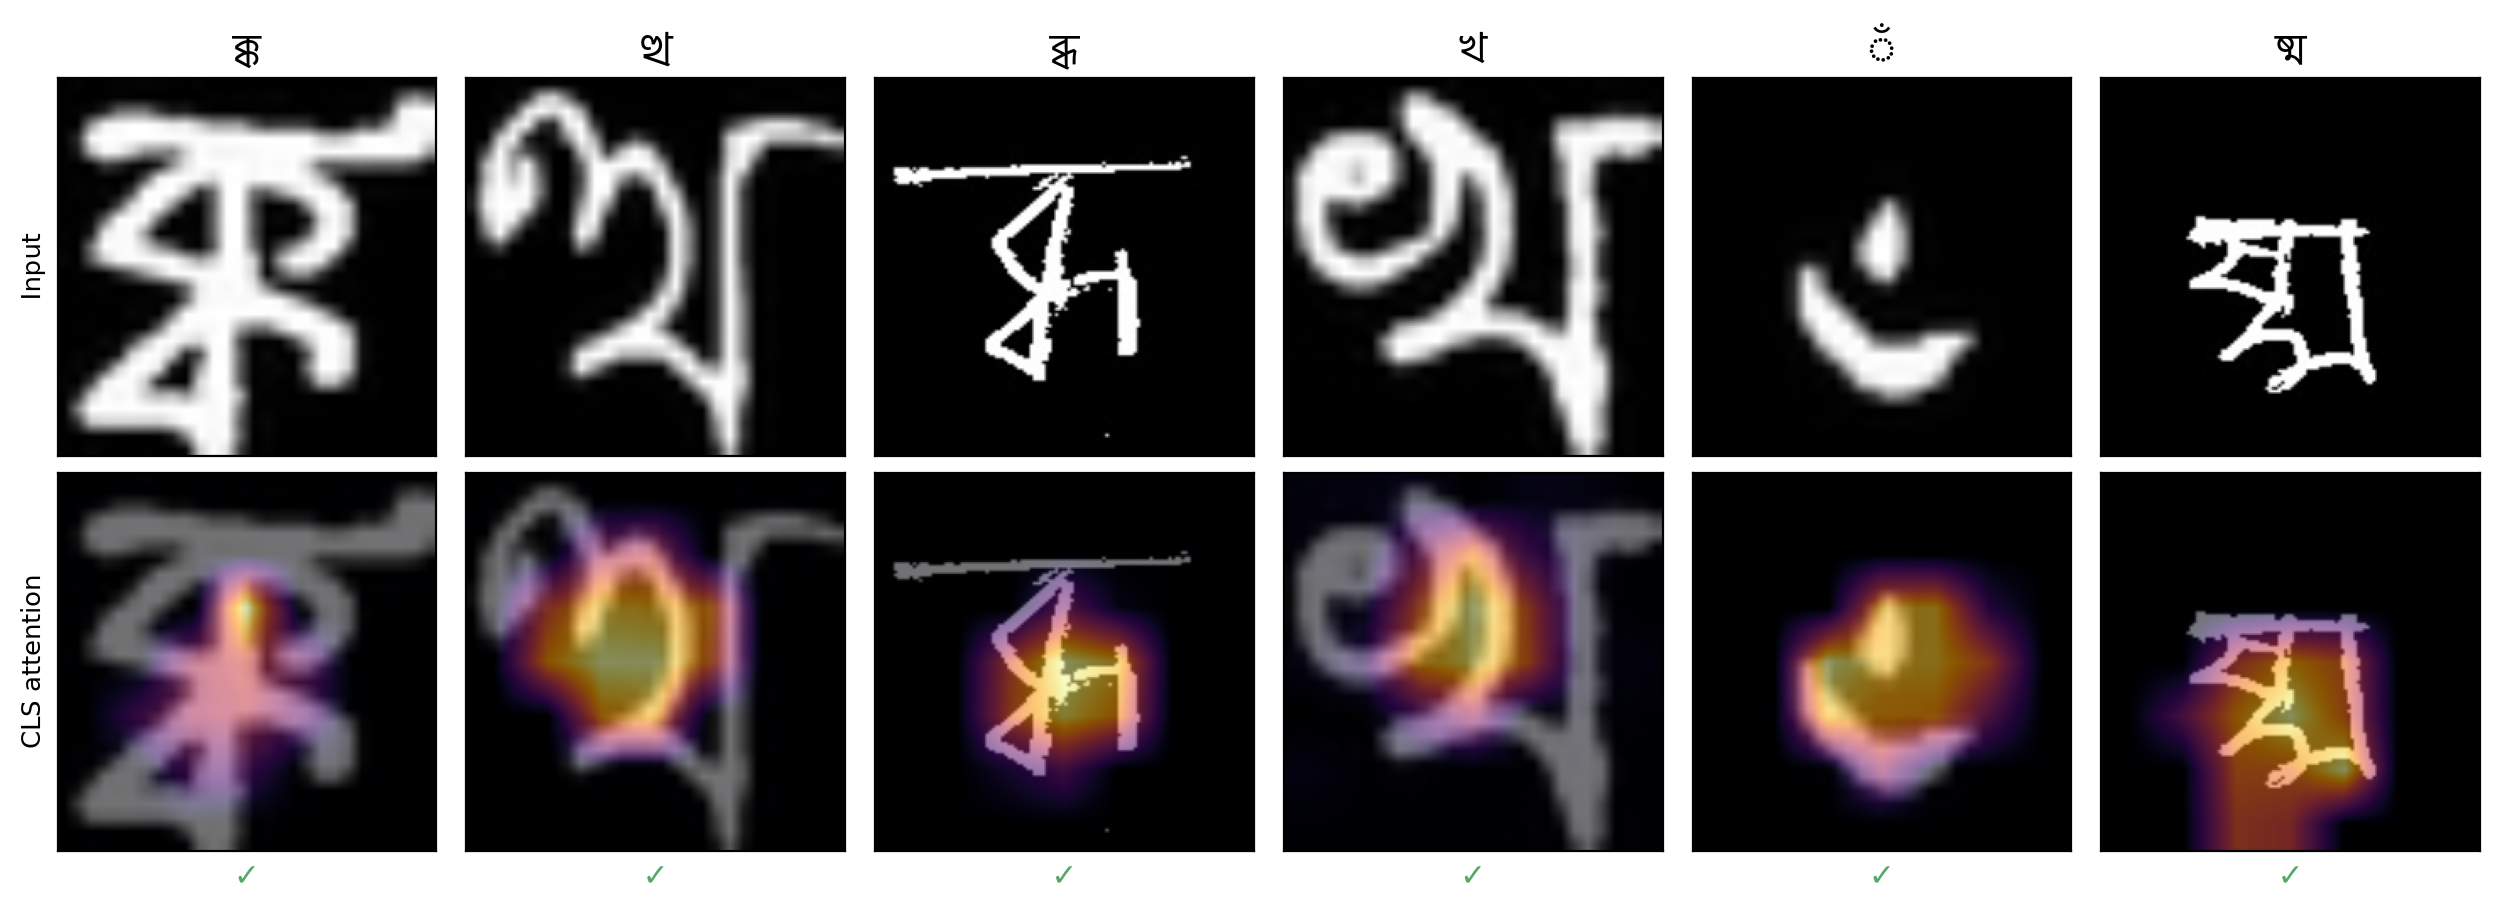

In [4]:
from IPython.display import Image, display
display(Image('../paper/fig8_attention.png'))

## CPU inference cost

In [5]:
import time, warnings
warnings.filterwarnings('ignore')  # timm imports tqdm.auto, which warns about ipywidgets
from train_arch import EVAL_BUILDERS
torch.set_num_threads(1)
x = torch.randn(1, 3, 224, 224)
print(f"{'model':16s} {'params':>12s} {'ms/image':>10s}")
for name, build in EVAL_BUILDERS.items():
    m = build(256).eval()
    with torch.no_grad():
        for _ in range(3): m(x)
        t0 = time.perf_counter()
        for _ in range(15): m(x)
    ms = (time.perf_counter() - t0) / 15 * 1000
    print(f'{name:16s} {sum(p.numel() for p in m.parameters()):>12,} {ms:>10.1f}')

model                  params   ms/image
cnn                    62,208        4.0


resnet18           11,307,840       12.0


vit                86,325,248       60.1


extended_vit       23,944,512       16.9
